# Module 1.3: 反向传播算法

## 1. 本章概览

### 📚 学习目标

1. **链式法则**：理解复合函数的求导
2. **计算图**：理解前向和反向传播的计算流程
3. **梯度计算**：手动计算神经网络的梯度
4. **完整训练**：实现完整的训练循环

### 🎯 核心问题

- 如何高效计算复杂函数的梯度？
- 反向传播的本质是什么？
- 如何训练神经网络？

### ⏱️ 预计学习时间：2-3小时

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)
print("✓ Libraries imported")

✓ Libraries imported


## 2. 动机与背景

### 为什么需要反向传播？

神经网络有数百万个参数，如何高效计算每个参数的梯度？

**朴素方法**：对每个参数单独求导 → $O(n)$ 次前向传播
**反向传播**：一次前向 + 一次反向 → $O(1)$ 次前向传播

---

## 3. 理论基础

### 3.1 链式法则 (Chain Rule)

链式法则是反向传播的数学核心。它描述了**如何对复合函数求导**——当函数是由多个简单函数嵌套而成时，整体导数等于各层导数的乘积。

---

#### 3.1.1 单变量链式法则

设 $y = f(g(x))$，其中 $u = g(x)$，则：

$$\frac{dy}{dx} = \frac{dy}{du} \cdot \frac{du}{dx}$$

**直觉**：$x$ 的微小变化先通过 $g$ 放大/缩小，再通过 $f$ 进一步放大/缩小，总效果是两次放缩的乘积。

**例**：$y = \sin(x^2)$

$$\frac{dy}{dx} = \cos(x^2) \cdot 2x$$

---

#### 3.1.2 多元链式法则

设 $z = f(x, y)$，而 $x = x(t)$，$y = y(t)$，则：

$$\frac{dz}{dt} = \frac{\partial z}{\partial x} \cdot \frac{dx}{dt} + \frac{\partial z}{\partial y} \cdot \frac{dy}{dt}$$

**关键**：当变量通过**多条路径**影响最终输出时，需要**把所有路径的贡献加起来**。

**计算图视角**（多路径梯度累加）：

```
        x
       / \
      /   \
     f     g
      \   /
       \ /
        z
```

$$\frac{\partial z}{\partial x} = \frac{\partial z}{\partial f} \cdot \frac{\partial f}{\partial x} + \frac{\partial z}{\partial g} \cdot \frac{\partial g}{\partial x}$$

> **重要规则**：节点有多条出边（影响多个后续节点）时，该节点的梯度 = 所有路径梯度之和。

---

#### 3.1.3 向量与矩阵的链式法则（Jacobian 矩阵）

在神经网络中，变量通常是向量或矩阵，链式法则推广为 **Jacobian 矩阵**相乘。

设 $\mathbf{y} = f(\mathbf{x})$，其中 $\mathbf{x} \in \mathbb{R}^n$，$\mathbf{y} \in \mathbb{R}^m$，则 Jacobian 矩阵为：

$$J = \frac{\partial \mathbf{y}}{\partial \mathbf{x}} = \begin{bmatrix}
\frac{\partial y_1}{\partial x_1} & \cdots & \frac{\partial y_1}{\partial x_n} \\
\vdots & \ddots & \vdots \\
\frac{\partial y_m}{\partial x_1} & \cdots & \frac{\partial y_m}{\partial x_n}
\end{bmatrix} \in \mathbb{R}^{m \times n}$$

设复合函数 $\mathbf{z} = f(g(\mathbf{x}))$，向量链式法则为：

$$\frac{\partial \mathbf{z}}{\partial \mathbf{x}} = \frac{\partial \mathbf{z}}{\partial \mathbf{y}} \cdot \frac{\partial \mathbf{y}}{\partial \mathbf{x}} = J_f \cdot J_g$$

**实际计算技巧**：在深度学习中，我们通常不显式构造完整 Jacobian，而是直接计算**向量-Jacobian 乘积（VJP）**，即已知上游梯度 $\mathbf{v}^T$，计算 $\mathbf{v}^T J$，这正是反向传播高效的原因。

---

#### 3.1.4 常用函数的导数速查表

| 函数 | 表达式 | 导数 | 说明 |
|------|--------|------|------|
| 线性 | $f(x) = ax + b$ | $a$ | 梯度为常数，不衰减 |
| Sigmoid | $\sigma(x) = \frac{1}{1+e^{-x}}$ | $\sigma(x)(1-\sigma(x))$ | 最大值 0.25，易梯度消失 |
| Tanh | $\tanh(x)$ | $1 - \tanh^2(x)$ | 最大值 1，比 Sigmoid 好 |
| ReLU | $\max(0, x)$ | $\mathbf{1}[x > 0]$ | 正区间梯度为 1，不消失 |
| Softmax | $\frac{e^{x_i}}{\sum_j e^{x_j}}$ | $p_i(\delta_{ij} - p_j)$ | 输出之和为 1 |
| MSE 损失 | $\frac{1}{2}(y - \hat{y})^2$ | $\hat{y} - y$ | 系数 $\frac{1}{2}$ 让导数简洁 |
| 矩阵乘法 | $z = Wx$ | $\frac{\partial L}{\partial W} = \delta x^T$，$\frac{\partial L}{\partial x} = W^T \delta$ | $\delta$ 为上游梯度 |

In [1]:
# 🔬 Micro Practice: Chain Rule
# Goal: Understand chain rule with concrete examples
# Expected outcome: Verify chain rule numerically

def f(x):
    """Outer function: f(y) = y^2"""
    return x**2

def g(x):
    """Inner function: g(x) = 2x + 1"""
    return 2*x + 1

def composite(x):
    """Composite function: f(g(x)) = (2x+1)^2"""
    return f(g(x))

# Analytical derivative using chain rule
# d/dx f(g(x)) = f'(g(x)) * g'(x) = 2*g(x) * 2 = 4*(2x+1)
def analytical_derivative(x):
    return 4 * (2*x + 1)

# Numerical derivative
def numerical_derivative(func, x, h=1e-5):
    return (func(x + h) - func(x)) / h

# Test
x = 3.0
analytical = analytical_derivative(x)
numerical = numerical_derivative(composite, x)

print(f"Function: f(g(x)) = (2x+1)²")
print(f"At x = {x}:")
print(f"  Analytical derivative: {analytical}")
print(f"  Numerical derivative: {numerical:.6f}")
print(f"  Difference: {abs(analytical - numerical):.2e}")
print("\n✓ Chain rule verified!")

Function: f(g(x)) = (2x+1)²
At x = 3.0:
  Analytical derivative: 28.0
  Numerical derivative: 28.000040
  Difference: 4.00e-05

✓ Chain rule verified!


In [2]:
# 🔬 Micro Practice: 多元链式法则 & Jacobian 矩阵
# Goal: 验证多条路径梯度累加，以及向量函数的 Jacobian
# Expected outcome: 理解向量版链式法则是标量版的自然推广

import numpy as np

print("=" * 60)
print("一、多元链式法则：多路径梯度累加")
print("=" * 60)

# f(x) = x^2 + sin(x)，x 通过两条路径影响输出
# dL/dx = dL/d(x^2) * d(x^2)/dx  +  dL/d(sin(x)) * d(sin(x))/dx
#       = 1 * 2x                  +  1 * cos(x)
#       = 2x + cos(x)

x = np.pi / 4

def path1(x): return x ** 2
def path2(x): return np.sin(x)
def total(x): return path1(x) + path2(x)

# 解析梯度（多路径累加）
analytical = 2 * x + np.cos(x)
# 数值梯度
h = 1e-7
numerical = (total(x + h) - total(x - h)) / (2 * h)

print(f"f(x) = x² + sin(x),  x = π/4")
print(f"  路径1 梯度：d(x²)/dx = 2x = {2*x:.6f}")
print(f"  路径2 梯度：d(sin x)/dx = cos(x) = {np.cos(x):.6f}")
print(f"  累加后解析梯度：{analytical:.6f}")
print(f"  数值验证：{numerical:.6f}")
print(f"  误差：{abs(analytical - numerical):.2e}  ← 极小，验证通过")

print("\n" + "=" * 60)
print("二、Jacobian 矩阵（向量函数的导数）")
print("=" * 60)

# 向量函数：y = f(x)，x ∈ R^3，y ∈ R^2
# f1(x) = x0^2 + x1
# f2(x) = x1 * x2 + x0

def f_vec(x):
    return np.array([x[0]**2 + x[1],
                     x[1] * x[2] + x[0]])

x0 = np.array([1.0, 2.0, 3.0])

# 解析 Jacobian（2×3）
# J = [[∂f1/∂x0, ∂f1/∂x1, ∂f1/∂x2],
#      [∂f2/∂x0, ∂f2/∂x1, ∂f2/∂x2]]
# = [[2*x0, 1, 0],
#    [1, x2, x1]]
J_analytical = np.array([
    [2 * x0[0], 1,      0     ],
    [1,         x0[2],  x0[1] ]
])

# 数值 Jacobian
J_numerical = np.zeros((2, 3))
h = 1e-5
for i in range(3):
    dx = np.zeros(3); dx[i] = h
    J_numerical[:, i] = (f_vec(x0 + dx) - f_vec(x0 - dx)) / (2 * h)

print(f"x = {x0}")
print(f"\n解析 Jacobian (2×3)：\n{J_analytical}")
print(f"\n数值 Jacobian (2×3)：\n{J_numerical.round(6)}")
print(f"\n最大误差：{np.max(np.abs(J_analytical - J_numerical)):.2e}")

# 向量-Jacobian 乘积（VJP）：已知上游梯度 v，求 v^T J
v = np.array([1.0, -1.0])  # 上游梯度（标量损失对 y 的梯度）
vjp_analytical = v @ J_analytical  # shape: (3,)
vjp_numerical  = v @ J_numerical

print(f"\n向量-Jacobian 乘积（VJP）：v = {v}")
print(f"  解析 VJP = v^T J = {vjp_analytical}")
print(f"  数值 VJP       = {vjp_numerical.round(6)}")
print("\n✓ Jacobian 与 VJP 验证完毕 — 这就是自动微分（autograd）的核心操作")

一、多元链式法则：多路径梯度累加
f(x) = x² + sin(x),  x = π/4
  路径1 梯度：d(x²)/dx = 2x = 1.570796
  路径2 梯度：d(sin x)/dx = cos(x) = 0.707107
  累加后解析梯度：2.277903
  数值验证：2.277903
  误差：1.84e-09  ← 极小，验证通过

二、Jacobian 矩阵（向量函数的导数）
x = [1. 2. 3.]

解析 Jacobian (2×3)：
[[2. 1. 0.]
 [1. 3. 2.]]

数值 Jacobian (2×3)：
[[2. 1. 0.]
 [1. 3. 2.]]

最大误差：6.41e-11

向量-Jacobian 乘积（VJP）：v = [ 1. -1.]
  解析 VJP = v^T J = [ 1. -2. -2.]
  数值 VJP       = [ 1. -2. -2.]

✓ Jacobian 与 VJP 验证完毕 — 这就是自动微分（autograd）的核心操作


### 3.2 计算图 (Computational Graph)

计算图是理解反向传播的核心工具。它将任意复杂的计算过程拆解为一系列简单操作节点，使梯度计算变得系统化、可自动化。

---

#### 3.2.1 什么是计算图

**计算图**是一个有向无环图（DAG），其中：
- **节点（Node）**：表示一次运算（如加法、乘法、激活函数）
- **边（Edge）**：表示数据（张量）在节点间的流动
- **叶节点**：输入变量或参数
- **根节点**：最终输出（通常是损失值）

```
示例：z = (x + y) × w

叶节点       中间节点     根节点
  x ──┐
      ├──[+]── a ──[×]── z
  y ──┘            │
  w ───────────────┘
```

---

#### 3.2.2 局部梯度（Local Gradient）与上游梯度（Upstream Gradient）

反向传播的关键思想是将梯度计算分解为两部分：

| 概念 | 含义 | 来源 |
|------|------|------|
| **上游梯度** $\frac{\partial L}{\partial \text{out}}$ | 损失对本节点输出的梯度 | 从后层传来 |
| **局部梯度** $\frac{\partial \text{out}}{\partial \text{in}}$ | 本节点输出对输入的偏导 | 由节点的运算决定，可提前计算 |
| **下游梯度** $\frac{\partial L}{\partial \text{in}}$ | 传给前层的梯度 | 上游梯度 × 局部梯度 |

$$\underbrace{\frac{\partial L}{\partial \text{in}}}_{\text{下游梯度}} = \underbrace{\frac{\partial L}{\partial \text{out}}}_{\text{上游梯度（来自后层）}} \times \underbrace{\frac{\partial \text{out}}{\partial \text{in}}}_{\text{局部梯度（本节点）}}$$

> 每个节点只需知道自己的局部梯度和上游梯度，无需了解整个网络结构，这使得反向传播具有完美的**模块化**特性。

---

#### 3.2.3 基本门（Gate）的梯度行为

**① 加法门（Add Gate）—— 梯度分发器**

$$z = x + y \implies \frac{\partial z}{\partial x} = 1, \quad \frac{\partial z}{\partial y} = 1$$

上游梯度**原封不动**地分发给所有输入。加法门是梯度的"复印机"。

```
上游梯度 δ
    ↓
  [x + y]
   ↙   ↘
  δ     δ     ← 两个输入都收到相同的梯度
```

**② 乘法门（Multiply Gate）—— 梯度交换器**

$$z = x \cdot y \implies \frac{\partial z}{\partial x} = y, \quad \frac{\partial z}{\partial y} = x$$

输入 $x$ 的梯度是**另一个输入** $y$ 乘以上游梯度，反之亦然。乘法门是梯度的"交换机"。

```
上游梯度 δ
    ↓
  [x × y]
   ↙    ↘
δ·y    δ·x   ← x 的梯度含 y，y 的梯度含 x
```

> **实践启示**：若 $x$ 很大而 $y$ 很小，则 $y$ 的梯度（$\delta \cdot x$）会很大，而 $x$ 的梯度（$\delta \cdot y$）会很小，造成梯度不均衡——这是理解学习率调整、权重初始化的重要视角。

**③ Max 门（Max Gate）—— 梯度路由器**

$$z = \max(x, y) \implies \frac{\partial z}{\partial x} = \mathbf{1}[x > y], \quad \frac{\partial z}{\partial y} = \mathbf{1}[y > x]$$

上游梯度**只流向较大的输入**，较小的输入梯度为 0。ReLU 的工作原理正是如此。

```
上游梯度 δ
    ↓
[max(x, y)]
   ↙    ↘
  δ      0    ← 假设 x > y，梯度只流向 x
```

**④ Sigmoid 门**

$$\sigma(x) = \frac{1}{1+e^{-x}} \implies \frac{d\sigma}{dx} = \sigma(x)(1-\sigma(x))$$

```
上游梯度 δ
    ↓
  [σ(x)]
    ↓
δ · σ(x)(1-σ(x))   ← 导数最大为 0.25（x=0 时）
```

---

#### 3.2.4 梯度在多出边节点的累加

若一个节点的输出被**多个后续节点使用**，则该节点的梯度是来自所有后续节点梯度的**总和**：

```
         ┌──[f]── 输出1 → δ₁
x ───────┤
         └──[g]── 输出2 → δ₂

∂L/∂x = δ₁ · ∂f/∂x + δ₂ · ∂g/∂x
```

这对应多元链式法则中的路径求和，在 ResNet 等有分支结构的网络中非常重要。

---

#### 3.2.5 示例：完整的计算图推导

**计算** $z = (x + y) \times w$，$x=2, y=3, w=4$

**前向传播（存储中间值）**：
```
a = x + y = 5
z = a × w = 20
```

**反向传播（从 dL/dz = 1 开始）**：

| 步骤 | 节点 | 计算 | 结果 |
|------|------|------|------|
| 1 | 起点 | $\partial L / \partial z = 1$ | $1$ |
| 2 | 乘法门 | $\partial L / \partial w = \frac{\partial L}{\partial z} \cdot a = 1 \times 5$ | $5$ |
| 2 | 乘法门 | $\partial L / \partial a = \frac{\partial L}{\partial z} \cdot w = 1 \times 4$ | $4$ |
| 3 | 加法门 | $\partial L / \partial x = \frac{\partial L}{\partial a} \cdot 1 = 4 \times 1$ | $4$ |
| 3 | 加法门 | $\partial L / \partial y = \frac{\partial L}{\partial a} \cdot 1 = 4 \times 1$ | $4$ |

> 注意：反向传播的计算量与前向传播同量级——这正是其高效的关键所在。

In [3]:
# 🔬 Micro Practice: Gate Gradient Behaviors
# Goal: Verify add / multiply / max / sigmoid gate gradients
# Expected outcome: 直观感受不同运算节点的梯度行为

import numpy as np

def numerical_grad(f, val, h=1e-5):
    return (f(val + h) - f(val - h)) / (2 * h)

print("=" * 60)
print("基本门（Gate）梯度行为验证")
print("=" * 60)

# ── 1. 加法门 ──────────────────────────────────────────────
x, y = 3.0, 5.0
upstream = 2.0  # 上游梯度（模拟来自后层）

add_out = x + y
local_grad_x = 1.0  # ∂(x+y)/∂x = 1
local_grad_y = 1.0  # ∂(x+y)/∂y = 1

print("\n① 加法门  z = x + y")
print(f"   x={x}, y={y} → z={add_out}")
print(f"   上游梯度: {upstream}")
print(f"   ∂L/∂x = upstream × 1 = {upstream * local_grad_x}  (梯度原封不动传给 x)")
print(f"   ∂L/∂y = upstream × 1 = {upstream * local_grad_y}  (梯度原封不动传给 y)")

# ── 2. 乘法门 ──────────────────────────────────────────────
x, y = 3.0, 5.0
upstream = 2.0

mul_out = x * y
local_grad_x = y   # ∂(x·y)/∂x = y
local_grad_y = x   # ∂(x·y)/∂y = x

print("\n② 乘法门  z = x × y")
print(f"   x={x}, y={y} → z={mul_out}")
print(f"   上游梯度: {upstream}")
print(f"   ∂L/∂x = upstream × y = {upstream * local_grad_x}  (梯度 = 另一个输入 × 上游)")
print(f"   ∂L/∂y = upstream × x = {upstream * local_grad_y}  (梯度 = 另一个输入 × 上游)")

# 数值验证
num_dx = numerical_grad(lambda xi: xi * y, x) * upstream
num_dy = numerical_grad(lambda yi: x * yi, y) * upstream
print(f"   数值验证 ∂L/∂x ≈ {num_dx:.4f}, ∂L/∂y ≈ {num_dy:.4f}")

# ── 3. Max 门 ──────────────────────────────────────────────
x, y = 3.0, 5.0
upstream = 2.0

max_out = max(x, y)
local_grad_x = 1.0 if x > y else 0.0
local_grad_y = 1.0 if y > x else 0.0

print("\n③ Max 门  z = max(x, y)")
print(f"   x={x}, y={y} → z={max_out}  (y 更大)")
print(f"   上游梯度: {upstream}")
print(f"   ∂L/∂x = upstream × {local_grad_x} = {upstream * local_grad_x}  (x 较小，梯度为 0)")
print(f"   ∂L/∂y = upstream × {local_grad_y} = {upstream * local_grad_y}  (y 较大，梯度全部流向 y)")

# ── 4. Sigmoid 门 ──────────────────────────────────────────
x = 0.0   # x=0 时导数最大
upstream = 1.0

def sigmoid(x): return 1 / (1 + np.exp(-x))
sig_x = sigmoid(x)
local_grad = sig_x * (1 - sig_x)

print("\n④ Sigmoid 门  z = σ(x)")
print(f"   x={x} → σ(x)={sig_x:.4f}")
print(f"   局部梯度 σ'(x) = σ(1-σ) = {local_grad:.4f}  (最大值 0.25)")
for test_x in [-3, -1, 0, 1, 3]:
    s = sigmoid(test_x)
    d = s * (1 - s)
    print(f"   x={test_x:+d}: σ={s:.3f}, σ'={d:.4f}", "← 饱和区，梯度≈0" if abs(test_x) >= 3 else "")

# 数值验证
num_sig = numerical_grad(sigmoid, 0.0)
print(f"\n   数值验证 σ'(0) ≈ {num_sig:.6f}，解析值 = {sigmoid(0)*(1-sigmoid(0)):.6f}")
print("\n✓ 所有门的梯度行为验证完毕")

基本门（Gate）梯度行为验证

① 加法门  z = x + y
   x=3.0, y=5.0 → z=8.0
   上游梯度: 2.0
   ∂L/∂x = upstream × 1 = 2.0  (梯度原封不动传给 x)
   ∂L/∂y = upstream × 1 = 2.0  (梯度原封不动传给 y)

② 乘法门  z = x × y
   x=3.0, y=5.0 → z=15.0
   上游梯度: 2.0
   ∂L/∂x = upstream × y = 10.0  (梯度 = 另一个输入 × 上游)
   ∂L/∂y = upstream × x = 6.0  (梯度 = 另一个输入 × 上游)
   数值验证 ∂L/∂x ≈ 10.0000, ∂L/∂y ≈ 6.0000

③ Max 门  z = max(x, y)
   x=3.0, y=5.0 → z=5.0  (y 更大)
   上游梯度: 2.0
   ∂L/∂x = upstream × 0.0 = 0.0  (x 较小，梯度为 0)
   ∂L/∂y = upstream × 1.0 = 2.0  (y 较大，梯度全部流向 y)

④ Sigmoid 门  z = σ(x)
   x=0.0 → σ(x)=0.5000
   局部梯度 σ'(x) = σ(1-σ) = 0.2500  (最大值 0.25)
   x=-3: σ=0.047, σ'=0.0452 ← 饱和区，梯度≈0
   x=-1: σ=0.269, σ'=0.1966 
   x=+0: σ=0.500, σ'=0.2500 
   x=+1: σ=0.731, σ'=0.1966 
   x=+3: σ=0.953, σ'=0.0452 ← 饱和区，梯度≈0

   数值验证 σ'(0) ≈ 0.250000，解析值 = 0.250000

✓ 所有门的梯度行为验证完毕


In [4]:
# 🔬 Micro Practice: Computational Graph
# Goal: Implement simple computational graph with forward and backward
# Expected outcome: Understand gradient flow

class ComputationalGraph:
    """
    Simple computational graph for z = (x + y) * w
    """

    def forward(self, x, y, w):
        """
        Forward pass

        Args:
            x, y, w: Input values

        Returns:
            z: Output value
        """
        # Store intermediate values for backward pass
        self.x = x
        self.y = y
        self.w = w
        self.a = x + y  # Intermediate result
        self.z = self.a * w  # Final output
        return self.z

    def backward(self):
        """
        Backward pass - compute all gradients

        Returns:
            Dictionary of gradients
        """
        # Start from output: dz/dz = 1
        dz_dz = 1.0

        # Gradient of z w.r.t. w: dz/dw = a
        dz_dw = self.a * dz_dz

        # Gradient of z w.r.t. a: dz/da = w
        dz_da = self.w * dz_dz

        # Gradient of z w.r.t. x: dz/dx = dz/da * da/dx = w * 1
        dz_dx = dz_da * 1.0

        # Gradient of z w.r.t. y: dz/dy = dz/da * da/dy = w * 1
        dz_dy = dz_da * 1.0

        return {'x': dz_dx, 'y': dz_dy, 'w': dz_dw}

# Test
graph = ComputationalGraph()
x, y, w = 2.0, 3.0, 4.0

# Forward
z = graph.forward(x, y, w)
print(f"Forward: z = ({x} + {y}) × {w} = {z}")

# Backward
grads = graph.backward()
print(f"\nBackward (gradients):")
print(f"  ∂z/∂x = {grads['x']}")
print(f"  ∂z/∂y = {grads['y']}")
print(f"  ∂z/∂w = {grads['w']}")

# Verify numerically
def f_x(x): return (x + y) * w
def f_y(y): return (x + y) * w
def f_w(w): return (x + y) * w

print(f"\nNumerical verification:")
print(f"  ∂z/∂x ≈ {(f_x(x+1e-5) - f_x(x))/1e-5:.6f}")
print(f"  ∂z/∂y ≈ {(f_y(y+1e-5) - f_y(y))/1e-5:.6f}")
print(f"  ∂z/∂w ≈ {(f_w(w+1e-5) - f_w(w))/1e-5:.6f}")

Forward: z = (2.0 + 3.0) × 4.0 = 20.0

Backward (gradients):
  ∂z/∂x = 4.0
  ∂z/∂y = 4.0
  ∂z/∂w = 5.0

Numerical verification:
  ∂z/∂x ≈ 4.000000
  ∂z/∂y ≈ 4.000000
  ∂z/∂w ≈ 5.000000


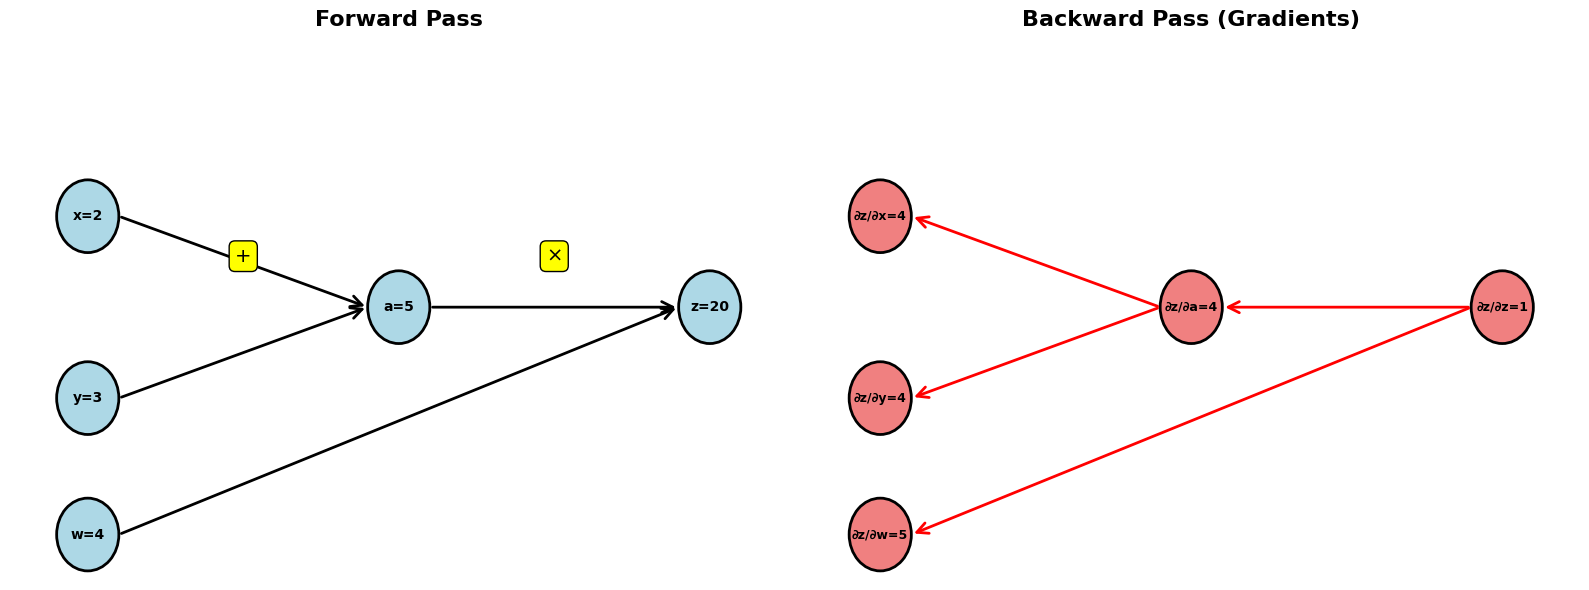

✓ 计算图展示了前向和反向传播的过程


In [6]:
# 🔬 Micro Practice: Visualize Computational Graph
# Goal: See the structure of forward and backward pass

import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Forward pass
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 6)
ax1.axis('off')
ax1.set_title('Forward Pass', fontsize=16, weight='bold')

# Nodes
nodes = [
    (1, 4, 'x=2'), (1, 2, 'y=3'), (1, 0.5, 'w=4'),
    (5, 3, 'a=5'), (9, 3, 'z=20')
]
for x, y, label in nodes:
    circle = mpatches.Circle((x, y), 0.4, color='lightblue', ec='black', linewidth=2)
    ax1.add_patch(circle)
    ax1.text(x, y, label, ha='center', va='center', fontsize=10, weight='bold')

# Edges
edges = [(1, 4, 5, 3), (1, 2, 5, 3), (5, 3, 9, 3), (1, 0.5, 9, 3)]
for x1, y1, x2, y2 in edges:
    arrow = FancyArrowPatch((x1+0.4, y1), (x2-0.4, y2),
                           arrowstyle='->', mutation_scale=20, linewidth=2, color='black')
    ax1.add_patch(arrow)

# Operations
ax1.text(3, 3.5, '+', fontsize=14, ha='center', bbox=dict(boxstyle='round', facecolor='yellow'))
ax1.text(7, 3.5, '×', fontsize=14, ha='center', bbox=dict(boxstyle='round', facecolor='yellow'))

# Backward pass
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 6)
ax2.axis('off')
ax2.set_title('Backward Pass (Gradients)', fontsize=16, weight='bold')

# Nodes with gradients
grad_nodes = [
    (1, 4, '∂z/∂x=4'), (1, 2, '∂z/∂y=4'), (1, 0.5, '∂z/∂w=5'),
    (5, 3, '∂z/∂a=4'), (9, 3, '∂z/∂z=1')
]
for x, y, label in grad_nodes:
    circle = mpatches.Circle((x, y), 0.4, color='lightcoral', ec='black', linewidth=2)
    ax2.add_patch(circle)
    ax2.text(x, y, label, ha='center', va='center', fontsize=9, weight='bold')

# Backward edges (reversed)
for x1, y1, x2, y2 in edges:
    arrow = FancyArrowPatch((x2-0.4, y2), (x1+0.4, y1),
                           arrowstyle='->', mutation_scale=20, linewidth=2, color='red')
    ax2.add_patch(arrow)

plt.tight_layout()
plt.show()

print("✓ 计算图展示了前向和反向传播的过程")

### 3.3 神经网络的反向传播

---

#### 🗺️ 整体思路：先"向前"预测，再"向后"纠错

反向传播分两个阶段，就像打靶：

| 阶段 | 方向 | 做什么 |
|------|------|--------|
| **前向传播** | 输入 → 输出 | 计算预测值，把中间结果"存档" |
| **反向传播** | 输出 → 输入 | 计算每个参数的责任（梯度），更新参数 |

---

#### 📐 网络结构

```
x  →  [W1, b1]  →  z1  →  σ  →  h  →  [W2, b2]  →  z2  →  σ  →  ŷ  →  L
输入    第一层权重    线性   激活  隐藏    第二层权重    线性   激活   预测   损失
```

---

#### ➡️ 第一步：前向传播（计算预测，存档中间值）

> 为什么要"存档"？反向传播计算梯度时会反复用到这些中间值，不提前保存就得重算。

$$z_1 = W_1 x + b_1 \quad \text{（隐藏层加权求和）}$$

$$h = \sigma(z_1) \quad \text{（通过激活函数，引入非线性）}$$

$$z_2 = W_2 h + b_2 \quad \text{（输出层加权求和）}$$

$$\hat{y} = \sigma(z_2) \quad \text{（通过激活函数，得到预测值）}$$

**损失函数**（均方误差，衡量预测与真实值的差距）：

$$L = \frac{1}{2}(\hat{y} - y)^2$$

> 乘以 $\frac{1}{2}$ 是为了让求导结果更简洁（导数恰好消掉系数 2）。

---

#### ⬅️ 第二步：反向传播（从误差出发，逐层追责）

反向传播从最右边（损失）出发，一路向左，用**链式法则**计算每个参数对误差的贡献。

---

**① 起点：损失对预测值的梯度**

$$\frac{\partial L}{\partial \hat{y}} = \hat{y} - y$$

> **直觉**：预测值比真实值大多少，梯度就是多少。这是整个反向传播的"误差信号源"。

---

**② 穿过输出层激活函数**

$$\frac{\partial L}{\partial z_2} = \frac{\partial L}{\partial \hat{y}} \cdot \sigma'(z_2)$$

> **直觉**：误差信号要经过激活函数"过滤"才能继续往回传。激活函数的导数 $\sigma'(z_2)$ 决定了信号能透过多少——这正是激活函数必须可微的原因。

---

**③ 计算输出层参数的梯度**

$$\frac{\partial L}{\partial W_2} = \frac{\partial L}{\partial z_2} \cdot h^T \qquad \frac{\partial L}{\partial b_2} = \frac{\partial L}{\partial z_2}$$

> **直觉**：$W_2$ 的梯度 = "后层传来的误差" × "前层的输出 $h$"。
> 哪个输入（$h$）越大，对应的权重（$W_2$）就要承担越多的"责任"，梯度也越大。
> 偏置 $b_2$ 不与任何输入相乘，所以其梯度就等于后层传来的误差本身。

---

**④ 将误差继续向前传递到隐藏层**

$$\frac{\partial L}{\partial h} = W_2^T \cdot \frac{\partial L}{\partial z_2}$$

> **直觉**：误差通过权重矩阵的**转置** $W_2^T$ 往回传。
> 正向时 $W_2$ 把 $h$ 变换到输出空间，反向时 $W_2^T$ 把误差"映射回"隐藏层空间。这是矩阵转置在反向传播中最核心的作用。

---

**⑤ 穿过隐藏层激活函数**

$$\frac{\partial L}{\partial z_1} = \frac{\partial L}{\partial h} \cdot \sigma'(z_1)$$

> **直觉**：和步骤②一样，误差再次被激活函数导数"过滤"。
> 若 $\sigma'(z_1) \approx 0$（如 Sigmoid 在饱和区），梯度几乎为零——这就是**梯度消失**问题的根源。

---

**⑥ 计算第一层参数的梯度**

$$\frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial z_1} \cdot x^T \qquad \frac{\partial L}{\partial b_1} = \frac{\partial L}{\partial z_1}$$

> **直觉**：与步骤③完全对称——用输入 $x$ 替换了 $h$，层层规律一致。

---

#### 🔄 第三步：参数更新（梯度下降）

所有梯度计算完毕后，按学习率 $\eta$ 更新每个参数：

$$W \leftarrow W - \eta \cdot \frac{\partial L}{\partial W}, \qquad b \leftarrow b - \eta \cdot \frac{\partial L}{\partial b}$$

> **为什么减去梯度？** 梯度指向损失增大最快的方向，我们要让损失减小，所以沿**梯度反方向**走。

---

#### 💡 关键规律总结

每一层的反向传播都遵循相同的三步模式：

```
① 接收来自后层的梯度
      ↓
② 乘以本层激活函数的导数（穿过非线性）
      ↓
③ 乘以本层输入的转置（计算权重梯度），同时通过权重转置把梯度传向前层
```

理解了这个模式，任意深度的网络反向传播都不再神秘。

In [7]:
# 🔬 Micro Practice: Complete Backpropagation Implementation
# Goal: Implement full forward and backward pass
# Expected outcome: Train a neural network on XOR problem

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    """Derivative of sigmoid: σ'(x) = σ(x)(1 - σ(x))"""
    s = sigmoid(x)
    return s * (1 - s)

class NeuralNetworkWithBackprop:
    """
    2-layer neural network with backpropagation
    """

    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.5):
        # Initialize weights
        self.W1 = np.random.randn(input_size, hidden_size) * 0.5
        self.b1 = np.zeros((1, hidden_size))
        self.W2 = np.random.randn(hidden_size, output_size) * 0.5
        self.b2 = np.zeros((1, output_size))
        self.learning_rate = learning_rate

    def forward(self, X):
        """Forward propagation"""
        self.z1 = X @ self.W1 + self.b1
        self.h = sigmoid(self.z1)
        self.z2 = self.h @ self.W2 + self.b2
        self.y_pred = sigmoid(self.z2)
        return self.y_pred

    def backward(self, X, y_true):
        """
        Backward propagation

        Args:
            X: Input features
            y_true: True labels
        """
        m = X.shape[0]  # Number of samples

        # Output layer gradients
        dL_dy_pred = self.y_pred - y_true
        dL_dz2 = dL_dy_pred * sigmoid_derivative(self.z2)

        # Gradients for W2 and b2
        dL_dW2 = (self.h.T @ dL_dz2) / m
        dL_db2 = np.sum(dL_dz2, axis=0, keepdims=True) / m

        # Hidden layer gradients
        dL_dh = dL_dz2 @ self.W2.T
        dL_dz1 = dL_dh * sigmoid_derivative(self.z1)

        # Gradients for W1 and b1
        dL_dW1 = (X.T @ dL_dz1) / m
        dL_db1 = np.sum(dL_dz1, axis=0, keepdims=True) / m

        # Update weights (gradient descent)
        self.W1 -= self.learning_rate * dL_dW1
        self.b1 -= self.learning_rate * dL_db1
        self.W2 -= self.learning_rate * dL_dW2
        self.b2 -= self.learning_rate * dL_db2

    def compute_loss(self, y_pred, y_true):
        """Mean squared error loss"""
        return np.mean((y_pred - y_true)**2)

    def train(self, X, y, epochs=10000, print_every=1000):
        """
        Train the network

        Args:
            X: Training features
            y: Training labels
            epochs: Number of training epochs
            print_every: Print loss every N epochs
        """
        losses = []

        for epoch in range(epochs):
            # Forward pass
            y_pred = self.forward(X)

            # Compute loss
            loss = self.compute_loss(y_pred, y)
            losses.append(loss)

            # Backward pass
            self.backward(X, y)

            # Print progress
            if (epoch + 1) % print_every == 0:
                print(f"Epoch {epoch+1}/{epochs}, Loss: {loss:.6f}")

        return losses

# Train on XOR problem
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([[0], [1], [1], [0]])

print("Training Neural Network on XOR Problem...")
print("="*50)

nn = NeuralNetworkWithBackprop(input_size=2, hidden_size=4, output_size=1, learning_rate=0.5)
losses = nn.train(X_xor, y_xor, epochs=10000, print_every=2000)

print("\nFinal Predictions:")
predictions = nn.forward(X_xor)
for i, (xi, yi, pred) in enumerate(zip(X_xor, y_xor, predictions)):
    print(f"Input: {xi}, True: {yi[0]}, Pred: {pred[0]:.4f}, Rounded: {round(pred[0])}")

print("\n✓ 网络成功学习了XOR函数！")

Training Neural Network on XOR Problem...
Epoch 2000/10000, Loss: 0.249795
Epoch 4000/10000, Loss: 0.243707
Epoch 6000/10000, Loss: 0.023895
Epoch 8000/10000, Loss: 0.005090
Epoch 10000/10000, Loss: 0.002649

Final Predictions:
Input: [0 0], True: 0, Pred: 0.0401, Rounded: 0
Input: [0 1], True: 1, Pred: 0.9493, Rounded: 1
Input: [1 0], True: 1, Pred: 0.9444, Rounded: 1
Input: [1 1], True: 0, Pred: 0.0577, Rounded: 0

✓ 网络成功学习了XOR函数！


/var/folders/bg/t1fd199x4b156z6xylpc7mfxdz85sm/T/ipykernel_13344/3035486773.py:28: RuntimeWarning: divide by zero encountered in matmul
  self.z1 = X @ self.W1 + self.b1
/var/folders/bg/t1fd199x4b156z6xylpc7mfxdz85sm/T/ipykernel_13344/3035486773.py:28: RuntimeWarning: overflow encountered in matmul
  self.z1 = X @ self.W1 + self.b1
/var/folders/bg/t1fd199x4b156z6xylpc7mfxdz85sm/T/ipykernel_13344/3035486773.py:28: RuntimeWarning: invalid value encountered in matmul
  self.z1 = X @ self.W1 + self.b1
/var/folders/bg/t1fd199x4b156z6xylpc7mfxdz85sm/T/ipykernel_13344/3035486773.py:30: RuntimeWarning: divide by zero encountered in matmul
  self.z2 = self.h @ self.W2 + self.b2
/var/folders/bg/t1fd199x4b156z6xylpc7mfxdz85sm/T/ipykernel_13344/3035486773.py:30: RuntimeWarning: overflow encountered in matmul
  self.z2 = self.h @ self.W2 + self.b2
/var/folders/bg/t1fd199x4b156z6xylpc7mfxdz85sm/T/ipykernel_13344/3035486773.py:30: RuntimeWarning: invalid value encountered in matmul
  self.z2 = self.h

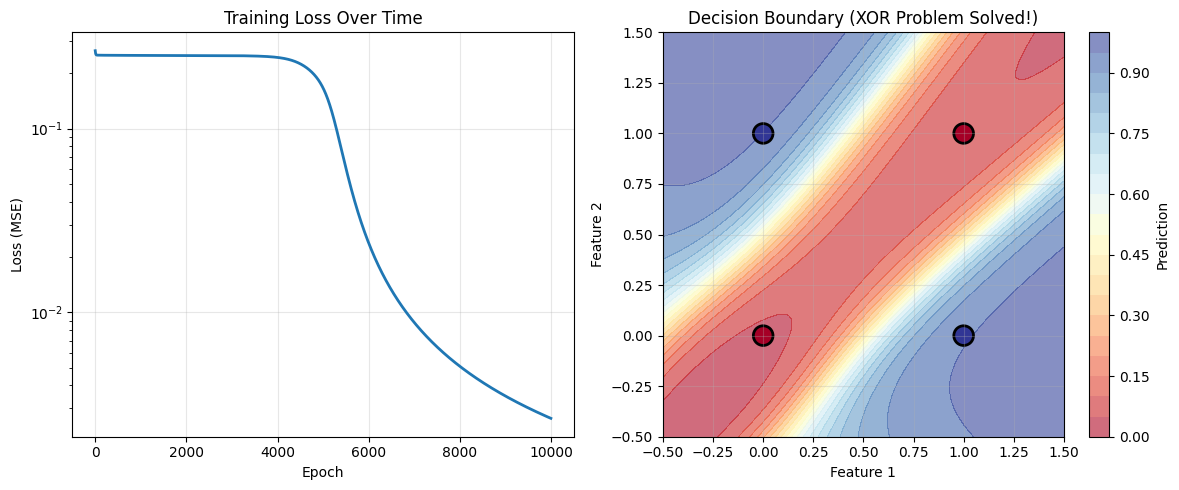

✓ 反向传播成功训练了神经网络！


In [8]:
# 🔬 Micro Practice: Visualize Training
# Goal: See how loss decreases during training

plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(losses, linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training Loss Over Time')
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Decision boundary
plt.subplot(1, 2, 2)
x_min, x_max = -0.5, 1.5
y_min, y_max = -0.5, 1.5
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100),
                     np.linspace(y_min, y_max, 100))
Z = nn.forward(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, levels=20, cmap='RdYlBu', alpha=0.6)
plt.colorbar(label='Prediction')
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor.ravel(),
           cmap='RdYlBu', s=200, edgecolors='black', linewidth=2)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundary (XOR Problem Solved!)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ 反向传播成功训练了神经网络！")

## 4-6. 实践总结

本章实现了：
- ✅ 链式法则的应用
- ✅ 计算图的前向和反向传播
- ✅ 完整的反向传播算法
- ✅ 训练神经网络解决XOR问题

## 7. 常见问题与调试

### Q1: 为什么需要保存前向传播的中间值？

**A:** 反向传播需要这些值来计算梯度。例如，计算 $\frac{\partial L}{\partial W_2}$ 需要隐藏层的激活值 $h$。

### Q2: 梯度消失和梯度爆炸是什么？

**A:**
- **梯度消失**：梯度变得非常小，权重几乎不更新（深层网络+Sigmoid）
- **梯度爆炸**：梯度变得非常大，权重更新过大（解决：梯度裁剪）

### Q3: 如何验证反向传播实现是否正确？

**A:** 使用**梯度检查**（gradient checking）：
- 数值梯度：$(f(x+h) - f(x-h)) / (2h)$
- 解析梯度：反向传播计算的梯度
- 比较两者，差异应该 < 1e-7

### Q4: 学习率如何选择？

**A:**
- 太大：不收敛，震荡
- 太小：收敛慢
- 常用：0.001, 0.01, 0.1
- 技巧：学习率衰减、自适应学习率（Adam）

## 8. 总结与展望

### 核心要点

1. **链式法则**：反向传播的数学基础
2. **计算图**：清晰表示前向和反向传播
3. **梯度计算**：从输出到输入逐层传播
4. **权重更新**：梯度下降优化参数

### 与其他技术的联系

```
链式法则 → 反向传播 → 梯度下降 → 训练神经网络
```

### 下一章预告

**Module 1.4: PyTorch基础**
- 自动微分
- 构建模型
- 训练循环

### 💡 思考题

1. 为什么反向传播比数值梯度快得多？
2. 如何处理梯度消失问题？
3. Batch Normalization如何影响反向传播？
4. 为什么需要激活函数的导数？

## 9. 思考题参考答案

### 问题 1：为什么反向传播比数值梯度快得多？

**核心原因：计算复杂度的本质差异**

**数值梯度（有限差分法）**：

对于拥有 $n$ 个参数的网络，每个参数 $\theta_i$ 的数值梯度需要独立进行一次前向传播：

$$\frac{\partial L}{\partial \theta_i} \approx \frac{L(\theta + h \cdot e_i) - L(\theta)}{h}$$

因此总共需要 $n$ 次前向传播，时间复杂度为 $O(n)$。

**反向传播（链式法则）**：

反向传播只需要 **1次前向传播 + 1次反向传播**，就能同时得到所有参数的梯度。

时间复杂度为 $O(1)$（相对于参数数量），即与前向传播同量级。

**对比示例**：

| 方法 | 参数量 $n$ | 所需前向传播次数 | 时间复杂度 |
|------|-----------|----------------|----------|
| 数值梯度 | 100万 | 100万次 | $O(n)$ |
| 反向传播 | 100万 | 1次 | $O(1)$ |

**本质原因**：反向传播利用了**链式法则的共享中间结果**特性。在反向传播中，每个节点的梯度只需计算一次，然后乘以从输出传回来的梯度即可。这种"梯度复用"避免了大量重复计算。

---

### 问题 2：如何处理梯度消失问题？

**梯度消失的成因**：

在深层网络中，反向传播时梯度需要逐层相乘。若每层的导数值 $|\sigma'(z)| < 1$（如 Sigmoid 函数，最大值为 0.25），则经过多层后梯度会指数级衰减：

$$\frac{\partial L}{\partial W_1} = \frac{\partial L}{\partial z_n} \cdot \prod_{k=2}^{n} \sigma'(z_k) \cdot W_k$$

**Sigmoid 导数范围**：$\sigma'(x) = \sigma(x)(1-\sigma(x)) \in (0, 0.25]$，10层后梯度缩小到 $0.25^{10} \approx 10^{-6}$。

**主要解决方案**：

1. **换用 ReLU 系激活函数**
   - ReLU：$f(x) = \max(0, x)$，导数为 1（正区间），不会衰减
   - Leaky ReLU、ELU、GELU 进一步缓解"死亡 ReLU"问题

2. **Batch Normalization**
   - 对每层输入进行归一化，将激活值控制在合理范围内
   - 使梯度在各层间保持稳定量级

3. **残差连接（Residual Connection）**
   - ResNet 的核心：$H(x) = F(x) + x$
   - 梯度可以直接通过恒等连接流回浅层，跳过多层非线性变换
   - 梯度中始终包含 $\frac{\partial x}{\partial x} = 1$ 的项，防止消失

4. **合理的权重初始化**
   - Xavier 初始化：$W \sim \mathcal{U}\left(-\sqrt{\frac{6}{n_{in}+n_{out}}}, \sqrt{\frac{6}{n_{in}+n_{out}}}\right)$
   - He 初始化（适配 ReLU）：$W \sim \mathcal{N}\left(0, \frac{2}{n_{in}}\right)$

5. **梯度裁剪（Gradient Clipping）**
   - 防止梯度爆炸的同时也有助于训练稳定性
   - `torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)`

---

### 问题 3：Batch Normalization 如何影响反向传播？

**Batch Normalization 前向传播**：

给定一个 mini-batch $\{x_1, \ldots, x_m\}$，BN 的计算流程为：

$$\mu_B = \frac{1}{m}\sum_{i=1}^m x_i \qquad \sigma_B^2 = \frac{1}{m}\sum_{i=1}^m (x_i - \mu_B)^2$$

$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}} \qquad y_i = \gamma \hat{x}_i + \beta$$

其中 $\gamma$（缩放）和 $\beta$（偏移）是可学习参数。

**对反向传播的影响**：

1. **梯度计算更复杂**：由于 $\mu_B$ 和 $\sigma_B^2$ 依赖于整个 batch，每个样本的梯度都与 batch 内其他样本相关：

$$\frac{\partial L}{\partial x_i} = \frac{\gamma}{m\sqrt{\sigma_B^2+\epsilon}} \left[ m\frac{\partial L}{\partial \hat{x}_i} - \sum_j \frac{\partial L}{\partial \hat{x}_j} - \hat{x}_i \sum_j \frac{\partial L}{\partial \hat{x}_j} \hat{x}_j \right]$$

2. **正面效果——缓解梯度消失/爆炸**：BN 将每层的输入归一化到均值为0、方差为1的分布附近，使激活函数始终工作在梯度较大的区间，防止梯度消失。

3. **允许更大学习率**：由于激活值被控制在合理范围，训练更加稳定，可以使用更大的学习率加速收敛。

4. **训练/推理模式差异**：训练时用当前 batch 的统计量，推理时（`model.eval()`）使用训练期间积累的**运行均值和方差**，这是 `model.train()` 和 `model.eval()` 必须区分的重要原因。

---

### 问题 4：为什么需要激活函数的导数？

**直接原因：链式法则的必然要求**

在反向传播中，计算损失对前层权重的梯度必须经过激活函数节点。以单层为例：

$$z = Wx + b, \quad a = \sigma(z), \quad L = f(a)$$

根据链式法则：

$$\frac{\partial L}{\partial W} = \frac{\partial L}{\partial a} \cdot \frac{\partial a}{\partial z} \cdot \frac{\partial z}{\partial W} = \frac{\partial L}{\partial a} \cdot \sigma'(z) \cdot x^T$$

其中 $\sigma'(z)$ 就是激活函数在 $z$ 处的导数。**没有激活函数的导数，梯度就无法从后层传递到前层的参数**。

**深层含义：激活函数可微性的必要性**

| 条件 | 后果 |
|------|------|
| 激活函数处处可微 | 梯度可在所有点流动（如 Sigmoid、Tanh） |
| 激活函数分段可微（如 ReLU） | 在非零点导数为1，零点次梯度为0，实践中可用 |
| 激活函数不可微（如 Sign 函数） | 无法用标准反向传播训练 |

**激活函数导数的双重作用**：

1. **传递梯度**：将后层的梯度信号乘以 $\sigma'(z)$ 后传向前层
2. **门控梯度**：$\sigma'(z)$ 的大小决定了梯度流动的"通畅程度"
   - $\sigma'(z) \approx 0$：梯度消失，前层参数几乎不更新（Sigmoid 饱和区的问题）
   - $\sigma'(z) = 1$（ReLU 正区间）：梯度完整传递，训练效率高

**实践启示**：选择激活函数时，需要在**非线性表达能力**和**梯度传递效率**之间取得平衡，这也是 ReLU 及其变体在现代深度学习中成为主流选择的根本原因。